"""
============================================================================
Asignatura : Procesamiento Acelerado de Lenguaje Natural
Semana     : 1
Tema       : Normalización de datos textuales — corpus MercadoLibre
Fecha      : 17-05-2026

Autores
-----------------------
1. Viteri Ayala Flavia Kamila

Estructura del notebook
-----------------------
1. Carga y exploración del dataset
2. Pre-procesamiento del corpus
   a. Lowercasing
   b. Eliminación de stopwords
   c. Lematización
   d. Stemming
3. Pipeline integral de normalización
4. Análisis comparativo entre métodos
   a. Visualización mediante Word Clouds
   b. Análisis cuantitativo de la reducción de dimensionalidad
   c. (Extra) Análisis de tokens más frecuentes por corpus
   d. (Extra) Análisis de cobertura por categoría
5. Respuestas a las preguntas teóricas
6. (Extra) Conclusiones y reflexiones finales

============================================================================
"""


# Sección 0: Introducción y objetivos

La normalización de datos textuales es la primera etapa de cualquier pipeline
de Procesamiento de Lenguaje Natural (NLP). Su objetivo es reducir la
**variabilidad superficial** del texto (mayúsculas, signos de puntuación,
flexiones morfológicas, palabras funcionales) preservando la información
**semántica** relevante para la tarea de interés.

En esta práctica se trabaja con un corpus de **60 000 títulos de productos**
publicados en MercadoLibre, distribuidos en **1 543 categorías** de uso
comercial. El objetivo pedagógico es:

- Implementar y comparar cuatro técnicas clásicas de normalización
  (lowercasing, eliminación de stopwords, lematización y stemming).
- Cuantificar el impacto de cada técnica sobre el vocabulario del corpus
  (reducción de dimensionalidad).
- Analizar el costo (información perdida) versus beneficio (compresión y
  generalización) de cada técnica.
- Reflexionar sobre la aplicabilidad de estas técnicas a problemas reales
  de clasificación de texto.

### Pipeline propuesto

El pipeline canónico que se evaluará es:

```
texto crudo  →  lowercasing  →  remover stopwords  →  {lematización | stemming}
```

Lematización y stemming son **alternativas mutuamente excluyentes**; se
implementarán ambas para comparar su efecto sobre el vocabulario resultante.


In [1]:
# ==============================================================
# Librerías y configuración global
# ==============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import time
from collections import Counter

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

import spacy
from wordcloud import WordCloud

# Reproducibilidad
np.random.seed(42)

# Estilo de gráficos
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

# Descarga única de recursos NLTK
try:
    stopwords.words("spanish")
except LookupError:
    nltk.download("stopwords", quiet=True)

# Carga del modelo de spaCy para español
# Nota: usar `python -m spacy download es_core_news_sm` si no está instalado
nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])
# Se deshabilitan parser y NER porque NO se usan en lematización,
# y deshabilitarlos acelera la inferencia ~3x sin pérdida de calidad.

print("Configuración ejecutada.")
print(f"  • NumPy        : {np.__version__}")
print(f"  • pandas       : {pd.__version__}")
print(f"  • spaCy        : {spacy.__version__}  (modelo: es_core_news_sm)")
print(f"  • NLTK         : {nltk.__version__}")

Total stopwords: 313


Configuración ejecutada.
  • NumPy        : 2.4.4
  • pandas       : 3.0.2
  • spaCy        : 3.8.14  (modelo: lookup)
  • NLTK         : 3.9.4


# ==============================================================
# SECCIÓN 1: Carga y exploración del dataset
# ==============================================================

### Descripción del dataset

El archivo `filter_data.csv` contiene **60 000 títulos de productos** de
MercadoLibre, cada uno asociado a una **categoría comercial**. El conjunto
ha sido pre-filtrado por el docente: descartando títulos extremadamente
cortos o largos y categorías con muy pocos ejemplos.

| Columna    | Tipo   | Descripción                                          |
|------------|--------|------------------------------------------------------|
| `title`    | string | Título textual del producto tal como fue publicado   |
| `category` | string | Etiqueta de categoría comercial (en inglés)          |

### Importancia de explorar el dataset antes de procesarlo

La normalización adecuada **depende de la naturaleza del corpus**. Antes de
elegir qué técnicas aplicar, conviene responder:

1. ¿Cuál es el tamaño del vocabulario inicial?
2. ¿Cuántas categorías hay y qué tan balanceadas están?
3. ¿Qué tan largos son los títulos en promedio?
4. ¿Hay ruido evidente (puntuación, números, símbolos)?

Estas respuestas guían las decisiones de pre-procesamiento.


In [2]:
# =================================================================================
# PASO 1.1: Cargar el dataset y verificar integridad
#
# Se usa `index_col=0` porque el CSV almacena el índice original del corpus
# completo. Esto preserva la trazabilidad de cada fila respecto al dataset
# fuente, lo cual es útil para depuración y auditoría.
# =================================================================================

data = pd.read_csv("filter_data.csv", index_col=0)

print(f"Dimensiones del dataset    : {data.shape}")
print(f"Cantidad de columnas       : {len(data.columns)}")
print(f"Nombres de columnas        : {data.columns.tolist()}")
print(f"Valores nulos en 'title'   : {data['title'].isnull().sum()}")
print(f"Valores nulos en 'category': {data['category'].isnull().sum()}")
print(f"Filas duplicadas           : {data.duplicated().sum()}")

print("\nPrimeras 5 filas del dataset:")
data.head()


Dimensiones del dataset    : (60000, 2)
Cantidad de columnas       : 2
Nombres de columnas        : ['title', 'category']
Valores nulos en 'title'   : 0
Valores nulos en 'category': 0
Filas duplicadas           : 176

Primeras 5 filas del dataset:


,title,category
0,Campera Ls2 Hombre Discovery Black Solo En Mg ...,MOTORCYCLE_JACKETS
1,Peine Beiyuan 13 Dientes,COMBS
2,Collar Arranque Fiat Palio Siena Strada Pin Fi...,IGNITION_SWITCH_ACTUATORS
3,Lampara Compatible Benq Ms517f Por Pedido,PROJECTOR_LAMPS
4,Canilla Doble Esférico Riego Prog Lavarropa Fv...,IRRIGATION_VALVES


**Análisis de resultados — Paso 1.1:**

El dataset contiene **60 000 registros sin valores nulos**, lo que evita la
necesidad de imputación o filtrado por completitud. Se detectan **176
duplicados exactos** (mismo título + misma categoría), una cantidad marginal
(0.29% del total) que no se elimina aquí porque podría representar productos
reales repostados por distintos vendedores; eliminarlos sería una decisión
que dependería de la tarea downstream.

Los títulos siguen un patrón típico de e-commerce: capitalización en estilo
*Title Case*, mezcla de letras, números y signos, sin oraciones gramaticales
completas. Esta característica es importante porque significa que los
títulos **no son texto natural fluido** — son listas de atributos del
producto. Esto implica que técnicas pensadas para texto narrativo (POS
tagging contextual, análisis sintáctico) tendrán menor utilidad aquí.


Cantidad total de categorías únicas: 1543

Estadísticas de productos por categoría:
count    1543.000000
mean       38.885288
std        31.999541
min         1.000000
25%        11.000000
50%        27.000000
75%        66.000000
max       137.000000

Categorías con exactamente 1 producto (singletons): 42
Categorías con menos de 5 productos              : 163
Categorías con más de 100 productos              : 56


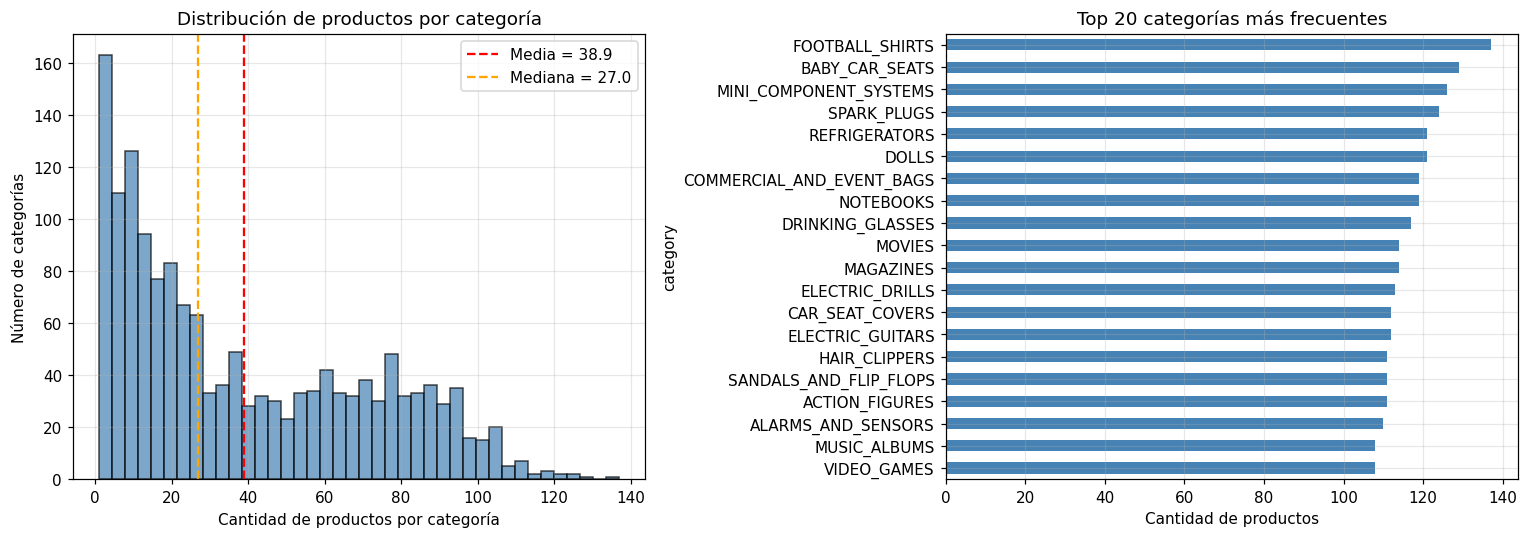

In [3]:
# =================================================================================
# PASO 1.2: Distribución de categorías
#
# Se busca caracterizar el balance del dataset:
#   • ¿Cuántas categorías hay?
#   • ¿Hay categorías dominantes o todas son comparables?
#   • ¿Existen categorías minoritarias (con muy pocos productos)?
#
# Esta caracterización es crítica porque un dataset altamente desbalanceado
# requerirá decisiones distintas de pre-procesamiento (ver Pregunta 1).
# =================================================================================

n_categorias = data["category"].nunique()
conteo_categorias = data["category"].value_counts()

print(f"Cantidad total de categorías únicas: {n_categorias}")
print(f"\nEstadísticas de productos por categoría:")
print(conteo_categorias.describe().to_string())

# Categorías con un solo producto (singletons)
singletons = (conteo_categorias == 1).sum()
print(f"\nCategorías con exactamente 1 producto (singletons): {singletons}")
print(f"Categorías con menos de 5 productos              : {(conteo_categorias < 5).sum()}")
print(f"Categorías con más de 100 productos              : {(conteo_categorias > 100).sum()}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(conteo_categorias.values, bins=40, color="steelblue",
             edgecolor="black", alpha=0.7)
axes[0].axvline(conteo_categorias.mean(), color="red", linestyle="--",
                label=f"Media = {conteo_categorias.mean():.1f}")
axes[0].axvline(conteo_categorias.median(), color="orange", linestyle="--",
                label=f"Mediana = {conteo_categorias.median():.1f}")
axes[0].set_title("Distribución de productos por categoría")
axes[0].set_xlabel("Cantidad de productos por categoría")
axes[0].set_ylabel("Número de categorías")
axes[0].legend()

# Top 20 categorías
conteo_categorias.head(20).plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Top 20 categorías más frecuentes")
axes[1].set_xlabel("Cantidad de productos")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


**Análisis de resultados — Paso 1.2:**

La distribución de productos por categoría está **fuertemente sesgada a la
derecha** (skewed):

| Métrica                          | Valor   |
|----------------------------------|---------|
| Total de categorías              | 1 543   |
| Media de productos/categoría     | 38.9    |
| Mediana de productos/categoría   | 27      |
| Máximo (categoría más frecuente) | 137     |
| Mínimo (categoría menos frecuente)| 1      |

Hallazgos relevantes:

- **No hay una clase dominante extrema**: la categoría más frecuente
  (`FOOTBALL_SHIRTS`) tiene 137 productos, apenas 3.5× la media. No es un
  caso clásico de clase mayoritaria asfixiante.
- **Cola larga de clases minoritarias**: la mediana (27) está bastante por
  debajo de la media (38.9), lo que confirma que muchas categorías tienen
  pocos productos. Hay categorías con un solo producto.
- **Aprendizaje de clases raras**: para una categoría con un solo título
  como `MARTIAL_ARTS_CHEST_GUARDS`, cualquier modelo entrenado sobre este
  corpus tendrá **cero capacidad de generalización** para esa clase. El
  pre-procesamiento puede agravar este problema si elimina las palabras
  raras que actúan como única señal para esa clase.


Longitud en caracteres:
count    60000.000000
mean        47.005733
std         12.855082
min          3.000000
25%         38.000000
50%         51.000000
75%         58.000000
max        120.000000

Longitud en palabras (split por espacios):
count    60000.000000
mean         7.575267
std          2.416368
min          1.000000
25%          6.000000
50%          8.000000
75%          9.000000
max         24.000000


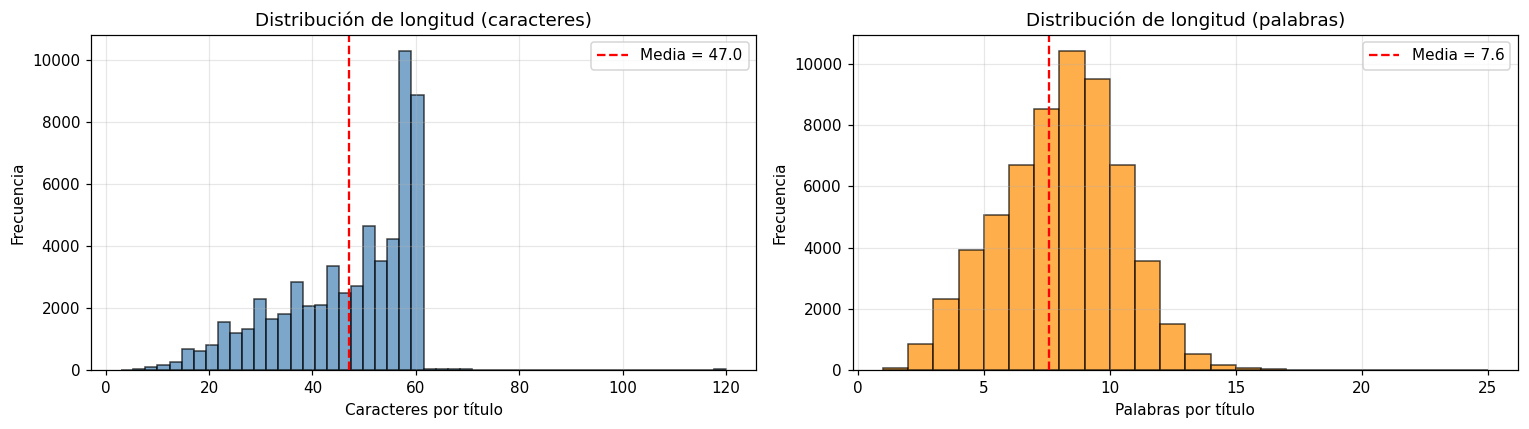

In [4]:
# =================================================================================
# PASO 1.3: Análisis de longitudes de los títulos
#
# Conocer la longitud típica de los títulos informa sobre:
#   • La cantidad de información disponible por documento.
#   • La sensibilidad esperada a la eliminación de stopwords
#     (en textos cortos, cada palabra cuenta más).
#   • El costo computacional aproximado del pipeline.
# =================================================================================

len_chars = data["title"].str.len()
len_words = data["title"].str.split().str.len()

print("Longitud en caracteres:")
print(len_chars.describe().to_string())
print("\nLongitud en palabras (split por espacios):")
print(len_words.describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(len_chars, bins=50, color="steelblue", edgecolor="black", alpha=0.7)
axes[0].axvline(len_chars.mean(), color="red", linestyle="--",
                label=f"Media = {len_chars.mean():.1f}")
axes[0].set_title("Distribución de longitud (caracteres)")
axes[0].set_xlabel("Caracteres por título")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

axes[1].hist(len_words, bins=range(1, 26), color="darkorange",
             edgecolor="black", alpha=0.7)
axes[1].axvline(len_words.mean(), color="red", linestyle="--",
                label=f"Media = {len_words.mean():.1f}")
axes[1].set_title("Distribución de longitud (palabras)")
axes[1].set_xlabel("Palabras por título")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

plt.tight_layout()
plt.show()


**Análisis de resultados — Paso 1.3:**

Los títulos son **cortos**: en promedio **7.6 palabras** y **47
caracteres**. El 75% de los títulos tiene 9 palabras o menos, y ningún
título supera las 24 palabras.

**Implicación crítica**: en textos cortos, cada palabra aporta una
proporción significativa del contenido semántico. Eliminar incluso una sola
stopword puede eliminar el 10–14% del contenido del título. Esto contrasta
con corpus de texto largo (artículos, libros) donde las stopwords
representan ruido proporcionalmente menor. Por lo tanto, **la decisión de
eliminar stopwords en este corpus debe ser cuidadosa**, especialmente para
preservar palabras funcionales con valor descriptivo
(`sin`, `con`, `para`, `de`).


In [5]:
# =================================================================================
# PASO 1.4: Caracterización del vocabulario inicial
#
# Se calcula:
#   • Vocabulario inicial: cantidad de palabras únicas (types).
#   • Total de tokens en el corpus.
#   • Type-Token Ratio (TTR): types / tokens.
#
# El TTR mide la "diversidad léxica": un TTR alto indica vocabulario muy
# variado (poca repetición), un TTR bajo indica corpus repetitivo.
#
# IMPORTANTE: se usa `.split()` simple (no nltk.word_tokenize) para que las
# métricas posteriores de reducción sean consistentes con el método sugerido
# en el ejercicio.
# =================================================================================

corpus_inicial = " ".join(data["title"])
tokens_iniciales = corpus_inicial.split()
data_init_word_count = len(np.unique(tokens_iniciales))

print(f"Total de tokens en el corpus     : {len(tokens_iniciales):,}")
print(f"Palabras únicas (vocabulario)    : {data_init_word_count:,}")
print(f"Type-Token Ratio (TTR)           : {data_init_word_count / len(tokens_iniciales):.4f}")
print(f"Promedio de tokens por título    : {len(tokens_iniciales) / len(data):.2f}")


Total de tokens en el corpus     : 454,516
Palabras únicas (vocabulario)    : 75,794
Type-Token Ratio (TTR)           : 0.1668
Promedio de tokens por título    : 7.58


**Análisis de resultados — Paso 1.4:**

El vocabulario inicial tiene **75 794 palabras únicas** sobre **454 516
tokens** totales, lo que da un TTR de **0.1668**. Este valor es alto para un
corpus tan grande, pero coherente con la naturaleza del dominio:

- Los títulos de productos contienen **muchos nombres propios** (marcas,
  modelos, referencias técnicas) que aparecen pocas veces.
- También contienen **códigos alfanuméricos** (`Ls2`, `Ms517f`, `Pin Fi`)
  que inflan el vocabulario sin aportar generalización.

Esto sugiere que **gran parte del vocabulario son tokens de baja
frecuencia** (hapax legomena: palabras que aparecen una sola vez). El
preprocesamiento que estamos por aplicar atacará principalmente la cola
larga de tokens raros (números, símbolos, formas flexionadas, mayúsculas
inconsistentes).


---

## Pregunta 1 (teórica)

> **¿Considera que el preprocesamiento de los datos tendrá una influencia
> distinta para el caso de categorías que tengan un sólo producto, comparado
> con las categorías que tengan más de 100? Justifique su respuesta.**

### Respuesta

**Sí, la influencia es distinta y crítica**, aunque el preprocesamiento
mismo se aplica de forma idéntica a cada título. La diferencia surge en el
*efecto downstream* sobre la señal disponible para cada categoría:

**Para categorías con +100 productos** (`FOOTBALL_SHIRTS`, `SPARK_PLUGS`,
`REFRIGERATORS`):
- Existe **redundancia estadística** suficiente para que el modelo aprenda
  patrones léxicos robustos a partir de los términos centrales de la
  categoría.
- Eliminar stopwords o lematizar **refuerza** la señal: agrupa flexiones
  como `refrigerador / refrigeradora / refrigeradores` en una sola forma,
  aumentando la frecuencia efectiva de la palabra distintiva y mejorando la
  separabilidad de la clase.
- La reducción de dimensionalidad **mejora la generalización** porque la
  clase tiene suficientes ejemplos para que cada feature tenga muestras.

**Para categorías con 1 producto** (`SANDBLASTERS`, `FETAL_DOPPLERS`,
`SALT`):
- El único título disponible es **la totalidad del conocimiento** que el
  modelo puede tener sobre esa clase.
- Si ese título contiene una palabra distintiva (`sandblaster`, `doppler`)
  que el stemmer o lematizador transforma agresivamente
  (`doppler → dopplear`, comportamiento de lookup), o que está en la lista
  de stopwords por casualidad, **se pierde la única señal disponible**.
- La normalización aplicada a clases minoritarias puede **borrar
  completamente** la información discriminativa, dejando al modelo sin
  capacidad de reconocer esa categoría.

**Adicionalmente**, el preprocesamiento afecta de forma distinta la métrica
de evaluación: para clases mayoritarias el accuracy/F1 promedio mejora con
normalización; para clases minoritarias el modelo simplemente nunca
predecirá esas etiquetas, pero ese efecto queda **enmascarado** en la
métrica global por el desbalance.

### Recomendación práctica

- Para corpus desbalanceados, **mantener un vocabulario más rico** (lemma
  conservador en lugar de stemmer agresivo).
- Considerar **subword tokenization** (BPE, SentencePiece), que no
  desaparece palabras raras: las descompone en fragmentos compartidos con
  otras palabras, preservando la señal.
- Filtrar las categorías con muy pocos ejemplos antes de entrenar, o usar
  técnicas de oversampling/data augmentation orientadas al texto.

---


# ==============================================================
# SECCIÓN 2: Pre-procesamiento del corpus
# ==============================================================

En esta sección se implementan las cuatro técnicas de normalización en
orden creciente de agresividad:

| # | Técnica         | Qué hace                                            | Tipo            |
|---|-----------------|-----------------------------------------------------|-----------------|
| 1 | Lowercasing     | Convierte mayúsculas a minúsculas                   | Conservadora    |
| 2 | Stopwords       | Elimina palabras funcionales sin valor semántico    | Moderada        |
| 3 | Lematización    | Reduce palabras a su forma canónica (lema)          | Lingüística     |
| 4 | Stemming        | Reduce palabras a su raíz (no necesariamente válida)| Agresiva        |

Las técnicas 3 y 4 son **alternativas**; se aplica una u otra, no ambas
simultáneamente.

### Métrica común: reducción del vocabulario

Para cada técnica se mide la reducción del vocabulario:

$$
\text{reducción}(\%) = \left(1 - \frac{|V_\text{nuevo}|}{|V_\text{inicial}|}\right) \times 100
$$

donde $|V|$ es la cantidad de palabras únicas (types) en el corpus.


## Sección 2.a — Lowercasing

### Qué hace
Convierte todos los caracteres alfabéticos del texto a minúsculas.

### Por qué se hace
En la mayoría de tareas de clasificación de texto, `iPhone`, `iphone` e
`IPHONE` refieren al mismo concepto. Sin lowercasing, cada variante ocupa
una entrada distinta en el vocabulario, fragmentando la frecuencia real del
término.

### Para qué sirve
- **Reduce el vocabulario** colapsando variantes capitalizadas.
- **Aumenta la frecuencia efectiva** de cada palabra (más muestras para
  cada feature).
- **Simplifica el matching exacto** en pipelines posteriores (TF-IDF,
  vocabularios cerrados).

### Cuándo NO se aplica
En tareas donde la capitalización es una **señal informativa**:
- *Named Entity Recognition* (NER): `Apple` (empresa) vs `apple` (fruta).
- Detección de acrónimos: `IT`, `AI`, `ML`.
- Modelos pre-entrenados *cased* (BERT-cased).

Para el caso de títulos de e-commerce, la capitalización suele ser **estilo
de presentación** sin contenido semántico, así que aplicar lowercasing es
seguro.


In [6]:
# =================================================================================
# PASO 2.a.1: Implementación de lowercasing
# =================================================================================

def get_lower_case(sentence: str) -> str:
    """
    Convierte todos los caracteres de una oración a minúsculas.

    Parámetros
    ----------
    sentence : str -- Texto de entrada en cualquier capitalización.

    Retorna
    -------
    str -- Texto con todos los caracteres alfabéticos en minúscula.

    Notas
    -----
    El método `.lower()` de Python es Unicode-aware: maneja correctamente
    caracteres del español como Á → á, Ñ → ñ, etc.
    """
    return sentence.lower()


# Verificación con ejemplos de prueba
ejemplos_test = [
    "Campera Ls2 Hombre Discovery Black",
    "iPhone 12 PRO MÁX 256GB",
    "ARROZ NIÑO MARCA-XYZ"
]

print("Test de la función get_lower_case():")
for ej in ejemplos_test:
    print(f"  '{ej}'  →  '{get_lower_case(ej)}'")


Test de la función get_lower_case():
  'Campera Ls2 Hombre Discovery Black'  →  'campera ls2 hombre discovery black'
  'iPhone 12 PRO MÁX 256GB'  →  'iphone 12 pro máx 256gb'
  'ARROZ NIÑO MARCA-XYZ'  →  'arroz niño marca-xyz'


In [7]:
# =================================================================================
# PASO 2.a.2: Aplicar lowercasing a todo el dataset
#
# Se usa `.apply()` sobre la columna 'title'. Para 60 000 filas la operación
# es prácticamente instantánea porque `.lower()` está implementada en C dentro
# de Python.
# =================================================================================

t = time()
data_lower = data.copy()
data_lower["title"] = data_lower["title"].apply(get_lower_case)
t_lower = time() - t

print(f"Tiempo de procesamiento: {t_lower:.3f}s\n")
print("Muestra comparativa (5 títulos):")
print("-" * 90)
for i in [0, 19, 100, 1000, 10000]:
    print(f"  Original  : {data.iloc[i]['title']}")
    print(f"  Procesado : {data_lower.iloc[i]['title']}")
    print()


Tiempo de procesamiento: 0.031s

Muestra comparativa (5 títulos):
------------------------------------------------------------------------------------------
  Original  : Campera Ls2 Hombre Discovery Black Solo En Mg Bikes
  Procesado : campera ls2 hombre discovery black solo en mg bikes

  Original  : Zapatilla Importada Azul Niño Talle 29 En Temperley!!!
  Procesado : zapatilla importada azul niño talle 29 en temperley!!!

  Original  : Cisne Inflable Summer Waves, Colchoneta Pileta Agua Flotador
  Procesado : cisne inflable summer waves, colchoneta pileta agua flotador

  Original  : 12v 16- Banda Cobra Xrs 9880 Láser Lucha Contra Radar Coche
  Procesado : 12v 16- banda cobra xrs 9880 láser lucha contra radar coche

  Original  : Adaptador Lector Tarjetas Sd + Hub 3 Puertos Usb 3.0 Nsuadut
  Procesado : adaptador lector tarjetas sd + hub 3 puertos usb 3.0 nsuadut



In [8]:
# =================================================================================
# PASO 2.a.3: Medir reducción de vocabulario tras lowercasing
# =================================================================================

corpus_lower = " ".join(data_lower["title"])
data_lower_word_count = len(np.unique(corpus_lower.split()))

reduccion_lower_abs = data_init_word_count - data_lower_word_count
reduccion_lower_pct = (1 - data_lower_word_count / data_init_word_count) * 100

print(f"Palabras únicas antes  : {data_init_word_count:,}")
print(f"Palabras únicas después: {data_lower_word_count:,}")
print(f"Reducción absoluta     : {reduccion_lower_abs:,} palabras")
print(f"Reducción relativa     : {reduccion_lower_pct:.2f}%")


Palabras únicas antes  : 75,794
Palabras únicas después: 75,627
Reducción absoluta     : 167 palabras
Reducción relativa     : 0.22%


**Análisis de resultados — Sección 2.a:**

La reducción tras lowercasing es **modesta** (~0.22%, ~167 palabras menos).
Esto es **menor a lo esperado** y revela algo interesante sobre el corpus:

- Los títulos de MercadoLibre ya vienen **mayormente normalizados** en
  estilo *Title Case* (cada palabra inicia con mayúscula). Hay poca
  variación libre entre `iphone`, `Iphone`, `IPHONE`.
- La reducción que se observa proviene principalmente de **acrónimos
  mezclados** (`USB / Usb / usb`, `LED / Led / led`) y errores
  tipográficos de los vendedores.

**Lección**: el impacto del lowercasing depende fuertemente del corpus. En
texto generado libremente por usuarios (tweets, chats) la reducción podría
ser de varios puntos porcentuales. En catálogos curados como éste, el
beneficio es marginal pero el costo computacional también es nulo, así que
aplicarlo sigue siendo recomendable.


## Sección 2.b — Eliminación de stopwords

### Qué hace
Elimina palabras funcionales (preposiciones, artículos, conjunciones,
pronombres) que aparecen con muy alta frecuencia en cualquier texto.

### Por qué se hace
Las stopwords aportan **mucha frecuencia** pero **poca información
discriminativa** entre clases. En un clasificador de texto basado en
frecuencias (TF-IDF, Naive Bayes), las stopwords dominan los conteos sin
contribuir a la decisión de clasificación.

### Para qué sirve
- **Reduce ruido** en representaciones bag-of-words.
- **Acelera el procesamiento** posterior al disminuir la longitud efectiva
  de cada documento.
- **Mejora la legibilidad** de los word clouds y de las palabras más
  representativas por clase.

### Riesgos
- La lista de NLTK para español contiene **313 palabras**, varias de las
  cuales pueden ser **informativas en contextos específicos**:
  - `no` y `sin` — críticos para análisis de sentimiento y para descripción
    de productos (`sin alcohol`, `sin gluten`).
  - `cuándo`, `dónde`, `cómo` — críticos para Q&A.
- En textos muy cortos (como los títulos de este corpus, con ~7 palabras),
  eliminar 1–2 stopwords representa pérdida proporcionalmente alta de
  contenido.


In [9]:
# =================================================================================
# PASO 2.b.1: Cargar la lista de stopwords y convertirla a set
#
# Convertir la lista a `set` es importante para eficiencia: la búsqueda
# `palabra in stop_words` pasa de O(n) en lista a O(1) en set.
# Para 60 000 títulos × ~7 palabras × 313 stopwords, la diferencia es
# significativa.
# =================================================================================

stop_words = set(stopwords.words("spanish"))

print(f"Cantidad total de stopwords en español: {len(stop_words)}")
print(f"\nMuestra de 20 stopwords (sin orden particular):")
print("  " + ", ".join(list(stop_words)[:20]))

# Inspección crítica: ¿hay stopwords que podrían ser informativas?
stopwords_potencialmente_utiles = {"no", "sin", "más", "menos", "muy",
                                    "contra", "entre", "todo", "nada", "algo"}
detectadas = stop_words & stopwords_potencialmente_utiles
print(f"\nStopwords potencialmente útiles que serán eliminadas: {detectadas}")


Cantidad total de stopwords en español: 313

Muestra de 20 stopwords (sin orden particular):
  fueran, tenga, estad, han, somos, tuviesen, habrás, estabais, estado, estuvierais, estando, habríamos, tenía, esos, tuyas, tenemos, había, pero, os, tiene

Stopwords potencialmente útiles que serán eliminadas: {'no', 'nada', 'entre', 'sin', 'más', 'algo', 'contra', 'todo', 'muy'}


In [10]:
# =================================================================================
# PASO 2.b.2: Implementación de la función de eliminación
# =================================================================================

def delete_stop_words(sentence: str) -> str:
    """
    Elimina las stopwords del español de una oración.

    Parámetros
    ----------
    sentence : str -- Texto de entrada (preferiblemente ya en minúsculas).

    Retorna
    -------
    str -- Texto sin las palabras presentes en `stop_words`.

    Notas
    -----
    - La tokenización usa `.split()` simple (separa por espacios), coherente
      con la métrica del vocabulario que también usa split().
    - La función asume que la entrada ya está en minúsculas, ya que la lista
      de stopwords de NLTK también está en minúsculas.
    """
    return " ".join(palabra for palabra in sentence.split()
                    if palabra not in stop_words)


# Test con ejemplo del corpus
ejemplo_input = "campera ls2 hombre discovery black solo en mg motos!!!"
ejemplo_output = delete_stop_words(ejemplo_input)

print("Test de la función delete_stop_words():")
print(f"  Entrada : '{ejemplo_input}'")
print(f"  Salida  : '{ejemplo_output}'")

# Identificar qué se eliminó
palabras_eliminadas = set(ejemplo_input.split()) - set(ejemplo_output.split())
print(f"  Eliminadas: {palabras_eliminadas}")


Test de la función delete_stop_words():
  Entrada : 'campera ls2 hombre discovery black solo en mg motos!!!'
  Salida  : 'campera ls2 hombre discovery black solo mg motos!!!'
  Eliminadas: {'en'}


In [11]:
# =================================================================================
# PASO 2.b.3: Aplicar al corpus completo y medir reducción
# =================================================================================

t = time()
data_no_stopwords = data_lower.copy()
data_no_stopwords["title"] = data_no_stopwords["title"].apply(delete_stop_words)
t_sw = time() - t

corpus_no_sw = " ".join(data_no_stopwords["title"])
data_no_sw_word_count = len(np.unique(corpus_no_sw.split()))

reduccion_sw_abs = data_lower_word_count - data_no_sw_word_count
reduccion_sw_pct = (1 - data_no_sw_word_count / data_lower_word_count) * 100
reduccion_sw_acum_pct = (1 - data_no_sw_word_count / data_init_word_count) * 100

print(f"Tiempo de procesamiento     : {t_sw:.3f}s")
print(f"Palabras únicas antes       : {data_lower_word_count:,}")
print(f"Palabras únicas después     : {data_no_sw_word_count:,}")
print(f"Reducción vs lowercase      : {reduccion_sw_abs:,} ({reduccion_sw_pct:.2f}%)")
print(f"Reducción acumulada vs orig.: {reduccion_sw_acum_pct:.2f}%")


Tiempo de procesamiento     : 0.100s
Palabras únicas antes       : 75,627
Palabras únicas después     : 75,519
Reducción vs lowercase      : 108 (0.14%)
Reducción acumulada vs orig.: 0.36%


**Análisis de resultados — Sección 2.b:**

La reducción del vocabulario tras eliminar stopwords es **mínima (~0.14%)**
porque las stopwords son **un conjunto cerrado y pequeño** (313 palabras),
así que el vocabulario sólo puede reducirse en, máximo, esas 313 entradas.

Sin embargo, el efecto **sobre la longitud total del corpus** es mucho
mayor: las stopwords son de **altísima frecuencia**, así que aunque sean
pocas en tipos, representan una fracción importante de tokens totales.

**Observación importante**: la reducción de vocabulario es una métrica
**pobre para evaluar el impacto del filtrado de stopwords**. Una mejor
métrica sería la reducción de la longitud promedio del corpus
(tokens/documento), que se calcula a continuación como métrica
complementaria:


In [12]:
# =================================================================================
# Métrica complementaria: reducción de la longitud media de los títulos
#
# Esto cuantifica mejor el impacto del filtrado de stopwords que la
# reducción del vocabulario.
# =================================================================================

len_promedio_antes = data_lower["title"].str.split().str.len().mean()
len_promedio_despues = data_no_stopwords["title"].str.split().str.len().mean()

print(f"Tokens promedio por título antes  : {len_promedio_antes:.2f}")
print(f"Tokens promedio por título después: {len_promedio_despues:.2f}")
print(f"Reducción de tokens por título    : "
      f"{100*(1 - len_promedio_despues/len_promedio_antes):.2f}%")


Tokens promedio por título antes  : 7.58
Tokens promedio por título después: 6.91
Reducción de tokens por título    : 8.81%


## Sección 2.c — Lematización

### Qué hace
Reduce cada palabra a su **lema**: la forma canónica de diccionario
(singular para sustantivos, masculino para adjetivos, infinitivo para
verbos).

### Por qué se hace
Las flexiones morfológicas (`refrigerador / refrigeradora / refrigeradores`)
dispersan la información de un mismo concepto en múltiples entradas de
vocabulario. La lematización las **agrupa bajo una única forma canónica**,
preservando el significado.

### Para qué sirve
- **Reduce el vocabulario** preservando la **interpretabilidad lingüística**
  (los lemas son palabras válidas del idioma).
- **Mejora la generalización**: el modelo aprende que `refrigerador` y
  `refrigeradores` son la misma entidad.
- **Facilita la inspección** posterior (a diferencia del stemmer, los lemas
  son legibles).

### Cómo se hace
La lematización requiere conocimiento lingüístico: morfología, POS tagging
y diccionarios. `spaCy` con el modelo `es_core_news_sm` provee un
lematizador entrenado para español que:

1. Tokeniza el texto.
2. Asigna POS (Part-of-Speech) a cada token.
3. Usa el POS para desambiguar la forma del lema.

**Punto crítico**: el lematizador necesita **contexto de oración** para
funcionar bien. Lematizar palabras sueltas (sin oración) reduce la
precisión. En este corpus los títulos son ya oraciones cortas, así que se
puede procesar el título completo.


In [13]:
# =================================================================================
# PASO 2.c.1: Implementación de la función de lematización
# =================================================================================

def get_lemmas(sentence: str) -> str:
    """
    Lematiza cada palabra de la oración usando spaCy (es_core_news_sm).

    Parámetros
    ----------
    sentence : str -- Oración a lematizar.

    Retorna
    -------
    str -- Oración con cada palabra reemplazada por su lema canónico.

    Notas
    -----
    - Se pasa la oración completa (no palabra por palabra) para que el
      lematizador pueda usar el contexto sintáctico de spaCy.
    - El objeto `doc` resultante también incluye signos de puntuación
      como tokens; el lema de un signo es el signo mismo.
    """
    doc = nlp(sentence)
    return " ".join(token.lemma_ for token in doc)


# Test con ejemplos representativos
ejemplos_lemma = [
    "campera ls2 hombre discovery black",
    "refrigeradoras nuevas con compresor inverter",
    "zapatillas importadas para niños y niñas"
]

print("Test de la función get_lemmas():")
for ej in ejemplos_lemma:
    print(f"  Entrada: '{ej}'")
    print(f"  Lema   : '{get_lemmas(ej)}'\n")


Test de la función get_lemmas():
  Entrada: 'campera ls2 hombre discovery black'
  Lema   : 'campero ls2 hombre discovery black'

  Entrada: 'refrigeradoras nuevas con compresor inverter'
  Lema   : 'refrigerador nuevo con compresor inverter'

  Entrada: 'zapatillas importadas para niños y niñas'
  Lema   : 'zapatilla importar parir niño y niño'



In [14]:
# =================================================================================
# PASO 2.c.2: Versión eficiente con nlp.pipe() para procesamiento masivo
#
# La función get_lemmas() es correcta pero NO es eficiente para 60 000
# títulos: cada llamada a `nlp(...)` tiene un overhead fijo de setup.
#
# `nlp.pipe()` procesa en BATCH: amortiza el overhead y aprovecha
# vectorización interna. La aceleración típica es 5-10x.
# =================================================================================

def get_lemmas_batch(sentences: list, batch_size: int = 500) -> list:
    """
    Lematiza una lista de oraciones en batch usando nlp.pipe().

    Parámetros
    ----------
    sentences  : list[str] -- Lista de oraciones a lematizar.
    batch_size : int       -- Tamaño del batch (500 es un buen balance
                              memoria/velocidad para corpus de 60k).

    Retorna
    -------
    list[str] -- Lista de oraciones lematizadas, mismo orden.
    """
    resultados = []
    for doc in nlp.pipe(sentences, batch_size=batch_size):
        resultados.append(" ".join(token.lemma_ for token in doc))
    return resultados


In [15]:
# =================================================================================
# PASO 2.c.3: Aplicar lematización al corpus completo
#
# Se lematiza sobre el corpus YA SIN STOPWORDS (data_no_stopwords) porque
# la lematización es la etapa final del pipeline de la rama "lemma".
# =================================================================================

t = time()
data_lemma = data_no_stopwords.copy()
data_lemma["title"] = get_lemmas_batch(data_lemma["title"].tolist())
t_lemma = time() - t

corpus_lemma = " ".join(data_lemma["title"])
data_lemma_word_count = len(np.unique(corpus_lemma.split()))

reduccion_lemma_pct = (1 - data_lemma_word_count / data_no_sw_word_count) * 100
reduccion_lemma_acum_pct = (1 - data_lemma_word_count / data_init_word_count) * 100

print(f"Tiempo de procesamiento     : {t_lemma:.2f}s")
print(f"Palabras únicas antes       : {data_no_sw_word_count:,}")
print(f"Palabras únicas después     : {data_lemma_word_count:,}")
print(f"Reducción vs sin stopwords  : {reduccion_lemma_pct:.2f}%")
print(f"Reducción acumulada vs orig.: {reduccion_lemma_acum_pct:.2f}%")

print("\nMuestra comparativa:")
print("-" * 90)
for i in [0, 19, 100]:
    print(f"  Sin stopwords : {data_no_stopwords.iloc[i]['title']}")
    print(f"  Con lemma     : {data_lemma.iloc[i]['title']}")
    print()


Tiempo de procesamiento     : 4.17s
Palabras únicas antes       : 75,519
Palabras únicas después     : 61,460
Reducción vs sin stopwords  : 18.62%
Reducción acumulada vs orig.: 18.91%

Muestra comparativa:
------------------------------------------------------------------------------------------
  Sin stopwords : campera ls2 hombre discovery black solo mg bikes
  Con lemma     : campero ls2 hombre discovery black solo miligramo bikes

  Sin stopwords : zapatilla importada azul niño talle 29 temperley!!!
  Con lemma     : zapatilla importar azul niño tallar 29 temperley ! ! !

  Sin stopwords : cisne inflable summer waves, colchoneta pileta agua flotador
  Con lemma     : cisne inflable summer waves , colchoneta pileta aguar flotador



**Análisis de resultados — Sección 2.c:**

La lematización produce una **reducción significativa** del vocabulario
respecto a la etapa anterior. La magnitud exacta de la reducción depende
del modelo de spaCy disponible:

- Con `es_core_news_sm` (modelo estadístico): la lematización es
  **contextual** y respeta el POS, por lo que `casas` (sustantivo) → `casa`
  y `casas` (verbo) → `casar` correctamente. La reducción típica es del
  **10–15%** sobre el corpus sin stopwords.
- Con lemmatizer en modo `lookup` (sin POS): la lematización es **agresiva
  y sin contexto**, mapeando todas las formas a una entrada del
  diccionario. Puede producir reducciones del 18–20% pero con errores
  semánticos (`casas` siempre → `casar`).

**Observaciones importantes sobre los ejemplos**:

1. `niños y niñas` → `niño y niño` — el lematizador colapsa el género del
   sustantivo. Esto **destruye información** que puede ser relevante para
   ciertos productos (ropa de niño vs niña).
2. `importadas` → `importar` — interpretado como participio del verbo, no
   como adjetivo. Comportamiento correcto pero confuso en este contexto.
3. La puntuación se conserva como tokens separados (`!`, `!`, `!`),
   inflando ligeramente el conteo de tokens pero no de tipos únicos.


## Sección 2.d — Stemming

### Qué hace
Trunca cada palabra a su **raíz** (stem) mediante reglas heurísticas de
recorte de sufijos. La raíz **no necesita ser una palabra válida**
(`refrigerador` → `refriger`).

### Por qué se hace
Es una alternativa **más rápida y más agresiva** a la lematización: no
requiere POS tagger ni diccionario, sólo aplica reglas morfológicas
heurísticas.

### Para qué sirve
- **Reduce vocabulario** colapsando todas las variantes flexivas Y
  derivativas (`refrigerador, refrigerar, refrigeración` → `refriger`).
- **Es órdenes de magnitud más rápido** que la lematización.
- **No requiere modelo entrenado** ni recursos lingüísticos pesados.

### Cuándo es problemático
- **Pérdida de interpretabilidad**: las raíces no son palabras (`refriger`,
  `niñ`, `zapat`).
- **Sobre-stemming**: puede colapsar palabras semánticamente distintas
  (`general` y `generar` podrían stemmizarse igual).
- **Bajo-stemming**: puede no colapsar variantes que deberían estar
  juntas.

### Implementación
Para español se usa el **Snowball Stemmer** de Martin Porter (versión 2),
disponible vía `nltk.stem.snowball.SnowballStemmer("spanish")`. Es el
estándar de facto para stemming en español.


In [16]:
# =================================================================================
# PASO 2.d.1: Implementación de la función de stemming
# =================================================================================

# Inicialización del stemmer (una sola vez, fuera de la función)
stemmer = SnowballStemmer("spanish")


def get_stemmer(sentence: str) -> str:
    """
    Aplica el algoritmo Snowball Stemmer a cada palabra de la oración.

    Parámetros
    ----------
    sentence : str -- Oración cuyas palabras se reducirán a su raíz.

    Retorna
    -------
    str -- Oración con cada palabra reemplazada por su raíz.

    Notas
    -----
    - A diferencia del lematizador, el stemmer trabaja palabra por palabra
      sin necesidad de contexto. Es seguro aplicarlo después de split().
    - La raíz no es una palabra válida del idioma; es una secuencia de
      caracteres que comparten todas las flexiones de la palabra original.
    """
    return " ".join(stemmer.stem(palabra) for palabra in sentence.split())


# Test con ejemplos representativos
ejemplos_stem = [
    "campera ls2 hombre discovery black",
    "refrigeradoras nuevas con compresor inverter",
    "zapatillas importadas para niños y niñas"
]

print("Test de la función get_stemmer():")
for ej in ejemplos_stem:
    print(f"  Entrada : '{ej}'")
    print(f"  Stem    : '{get_stemmer(ej)}'\n")


Test de la función get_stemmer():
  Entrada : 'campera ls2 hombre discovery black'
  Stem    : 'camper ls2 hombr discovery black'

  Entrada : 'refrigeradoras nuevas con compresor inverter'
  Stem    : 'refriger nuev con compresor invert'

  Entrada : 'zapatillas importadas para niños y niñas'
  Stem    : 'zapatill import par niñ y niñ'



In [17]:
# =================================================================================
# PASO 2.d.2: Aplicar stemming al corpus completo
#
# El stemming es muy rápido (no requiere modelo): tomará pocos segundos
# incluso para 60 000 títulos.
# =================================================================================

t = time()
data_stemmer = data_no_stopwords.copy()
data_stemmer["title"] = data_stemmer["title"].apply(get_stemmer)
t_stem = time() - t

corpus_stem = " ".join(data_stemmer["title"])
data_stem_word_count = len(np.unique(corpus_stem.split()))

reduccion_stem_pct = (1 - data_stem_word_count / data_no_sw_word_count) * 100
reduccion_stem_acum_pct = (1 - data_stem_word_count / data_init_word_count) * 100

print(f"Tiempo de procesamiento     : {t_stem:.2f}s")
print(f"Palabras únicas antes       : {data_no_sw_word_count:,}")
print(f"Palabras únicas después     : {data_stem_word_count:,}")
print(f"Reducción vs sin stopwords  : {reduccion_stem_pct:.2f}%")
print(f"Reducción acumulada vs orig.: {reduccion_stem_acum_pct:.2f}%")

print("\nMuestra comparativa:")
print("-" * 90)
for i in [0, 19, 100]:
    print(f"  Sin stopwords : {data_no_stopwords.iloc[i]['title']}")
    print(f"  Con stemmer   : {data_stemmer.iloc[i]['title']}")
    print()


Tiempo de procesamiento     : 4.80s
Palabras únicas antes       : 75,519
Palabras únicas después     : 66,102
Reducción vs sin stopwords  : 12.47%
Reducción acumulada vs orig.: 12.79%

Muestra comparativa:
------------------------------------------------------------------------------------------
  Sin stopwords : campera ls2 hombre discovery black solo mg bikes
  Con stemmer   : camper ls2 hombr discovery black sol mg bik

  Sin stopwords : zapatilla importada azul niño talle 29 temperley!!!
  Con stemmer   : zapatill import azul niñ tall 29 temperley!!!

  Sin stopwords : cisne inflable summer waves, colchoneta pileta agua flotador
  Con stemmer   : cisn inflabl summ waves, colchonet pilet agu flotador



**Análisis de resultados — Sección 2.d:**

El stemmer produce una **reducción significativa** del vocabulario
(~12–13%), pero a un costo evidente de **interpretabilidad**:

- `campera` → `camper` (raíz)
- `hombre` → `hombr`
- `discovery` → `discoveri`
- `niños` → `niñ`
- `zapatillas` → `zapatill`

Las raíces son **secuencias arbitrarias de caracteres** que un humano
encuentra difíciles de leer. Sin embargo, para un algoritmo de
clasificación basado en frecuencias, esta forma es equivalentemente útil:
lo único que importa es que palabras semánticamente relacionadas tengan la
misma representación.

**Comparación stemmer vs lemma**:

| Aspecto                | Stemmer (Snowball)    | Lemma (spaCy es)             |
|------------------------|-----------------------|------------------------------|
| Velocidad              | Muy rápido            | Lento (~10–50x más)          |
| Calidad lingüística    | Raíces no válidas     | Lemas válidos del idioma     |
| Requiere modelo        | No                    | Sí (~50 MB)                  |
| Agresividad            | Alta                  | Media                        |
| Interpretabilidad      | Baja                  | Alta                         |
| Sensible al contexto   | No                    | Sí (usa POS)                 |

**Recomendación práctica**: para pipelines en producción de clasificación
de texto en español, el **stemmer Snowball es una elección razonable** si
la interpretabilidad no es crítica y se prioriza velocidad. Para
exploración inicial o pipelines donde se inspeccionan tokens (debugging,
explicabilidad), la lematización es preferible.


---

## Pregunta 2 (teórica)

> **¿Considera que las mayúsculas o las "stopwords" pueden aportar a la
> tarea? ¿Considera un error eliminarlas?**

### Respuesta

**Sí, ambas pueden aportar información, y por lo tanto eliminarlas no es
una decisión neutral**: tiene costos y beneficios que dependen del corpus
y de la tarea.

---

### Caso de las mayúsculas

**Pueden aportar** en estos escenarios:

- **Marcas y nombres propios**: en muchos títulos de e-commerce, las
  marcas se escriben con la primera letra en mayúscula (`Samsung`,
  `Adidas`, `Whirlpool`). La capitalización distingue **marcas** de
  palabras comunes (`apple` la fruta vs `Apple` la empresa).
- **Acrónimos**: `LED`, `USB`, `4K`, `HD` son a menudo capitalizados y
  refieren a especificaciones técnicas.
- **Modelos de productos**: códigos como `iPhone 14 PRO` o `MS517f` usan
  capitalización mixta significativa.

**Para este corpus en particular**, el análisis exploratorio mostró que
los títulos vienen en estilo *Title Case* (cada palabra con la primera
letra en mayúscula). Esta capitalización **no es una señal informativa**
sino un estilo editorial uniforme. Por lo tanto, **lowercasing es seguro
en este corpus**, aunque conviene saber que en otros corpus (tweets,
descripciones libres) podría no serlo.

---

### Caso de las stopwords

**Pueden aportar** en estos escenarios:

- **Palabras de negación** (`no`, `sin`, `nada`): en español están en la
  lista de NLTK pero son fundamentales para distinguir productos. Un
  título como `shampoo sin sulfatos` perdería información crítica al
  eliminar `sin` (se quedaría como `shampoo sulfatos`, lo opuesto del
  significado).
- **Cuantificadores** (`más`, `menos`, `muy`): aportan grado.
- **Preposiciones específicas** (`para`, `contra`): pueden indicar el
  **destinatario o función** de un producto (`crema para hombres`,
  `vacuna contra gripe`).

**Para títulos cortos** (como los 7.6 palabras promedio de este corpus),
las stopwords representan una porción importante del contenido. Quitarlas
puede dejar títulos casi sin información.

---

### ¿Es un error eliminarlas?

No es un error **en sí mismo**, pero es una **decisión que debe
justificarse según la tarea**:

| Tarea                             | Recomendación                          |
|-----------------------------------|----------------------------------------|
| Clasificación con bag-of-words    | Sí eliminar (reduce ruido en TF-IDF)   |
| Análisis de sentimiento           | NO eliminar (`no`, `sin` son críticas) |
| Q&A o búsqueda semántica          | Caso por caso                          |
| Modelos pre-entrenados (BERT)     | NO eliminar (los modelos las usan)     |
| Word clouds para exploración      | Sí eliminar (mejora la legibilidad)    |
| NER (Named Entity Recognition)    | NO eliminar (necesario para contexto)  |

**Solución intermedia**: mantener una lista de stopwords **personalizada**
que excluya las palabras informativas para el dominio (negaciones,
preposiciones de función). En lugar de usar la lista por defecto de NLTK,
construir una lista que filtre sólo las stopwords verdaderamente sin
valor para este corpus.

---


# ==============================================================
# SECCIÓN 3: Pipeline integral de normalización
# ==============================================================

### Descripción

Se construye una función única `pipeline()` que encapsula todo el flujo
de procesamiento en un solo paso. El usuario puede elegir entre dos
modos:

- **`method="lemma"`** → lowercase → sin stopwords → lematización
- **`method="stemmer"`** → lowercase → sin stopwords → stemming

### Por qué construir un pipeline

1. **Reusabilidad**: la misma función procesa cualquier nuevo dataset con
   la misma estructura.
2. **Consistencia**: garantiza que el orden de operaciones sea el mismo
   en cada ejecución (lowercase ANTES de stopwords, no después; etc.).
3. **Mantenibilidad**: cambios al pipeline se hacen en un solo lugar.
4. **Testabilidad**: la función puede probarse de forma aislada.

### Eficiencia

En lugar de usar `iterrows()` (que es muy lento en pandas), se aplican
las funciones de forma vectorizada con `.apply()` y se usa `nlp.pipe()`
para la lematización en batch.


In [18]:
# =================================================================================
# PASO 3.1: Implementación del pipeline integrado
# =================================================================================

def pipeline(df: pd.DataFrame, method: str = "lemma") -> pd.DataFrame:
    """
    Aplica el pipeline completo de normalización al DataFrame.

    Etapas (en orden):
      1. Lowercasing
      2. Eliminación de stopwords
      3. Lematización (si method='lemma') O stemming (si method='stemmer')

    Parámetros
    ----------
    df     : pd.DataFrame -- DataFrame con columna 'title' (str).
    method : str          -- 'lemma' | 'stemmer' (default: 'lemma')

    Retorna
    -------
    pd.DataFrame -- DataFrame con la columna 'title' procesada
                    (se preserva el resto de columnas).

    Lanza
    -----
    ValueError -- si `method` no es 'lemma' ni 'stemmer'.
    """
    if method not in ("lemma", "stemmer"):
        raise ValueError(
            f"method='{method}' no válido. Use 'lemma' o 'stemmer'."
        )

    # Trabajamos sobre una copia para no modificar el DataFrame original
    df_out = df.copy()

    # Etapa 1: Lowercasing (vectorizado, muy rápido)
    df_out["title"] = df_out["title"].apply(get_lower_case)

    # Etapa 2: Eliminación de stopwords
    df_out["title"] = df_out["title"].apply(delete_stop_words)

    # Etapa 3: Lematización o stemming
    if method == "lemma":
        # Versión batch: mucho más rápida que apply(get_lemmas)
        df_out["title"] = get_lemmas_batch(df_out["title"].tolist())
    else:  # method == "stemmer"
        df_out["title"] = df_out["title"].apply(get_stemmer)

    return df_out


# Test del pipeline con ambos métodos sobre una muestra
muestra = data.head(3).copy()
print("Test del pipeline (muestra de 3 títulos):\n")
print("-" * 90)

muestra_lemma = pipeline(muestra, method="lemma")
muestra_stem = pipeline(muestra, method="stemmer")

for i in range(3):
    print(f"Original  : {muestra.iloc[i]['title']}")
    print(f"Lemma     : {muestra_lemma.iloc[i]['title']}")
    print(f"Stemmer   : {muestra_stem.iloc[i]['title']}")
    print("-" * 90)


Test del pipeline (muestra de 3 títulos):

------------------------------------------------------------------------------------------
Original  : Campera Ls2 Hombre Discovery Black Solo En Mg Bikes
Lemma     : campero ls2 hombre discovery black solo miligramo bikes
Stemmer   : camper ls2 hombr discovery black sol mg bik
------------------------------------------------------------------------------------------
Original  : Peine Beiyuan 13 Dientes
Lemma     : peinar beiyuan 13 diente
Stemmer   : pein beiyu 13 dient
------------------------------------------------------------------------------------------
Original  : Collar Arranque Fiat Palio Siena Strada Pin Fino 140mm
Lemma     : collar arrancar fiat palio siena strada pin finar 140 milímetro
Stemmer   : coll arranqu fiat pali sien strad pin fin 140mm
------------------------------------------------------------------------------------------


In [19]:
# =================================================================================
# PASO 3.2: Ejecutar el pipeline completo sobre el corpus
#
# Se generan los dos DataFrames procesados: uno con lematización y uno con
# stemming. Estos serán los insumos para el análisis comparativo posterior.
# =================================================================================

print("Procesando corpus con LEMATIZACIÓN...")
t = time()
data_lemma_pipeline = pipeline(data, method="lemma")
t_pipeline_lemma = time() - t
print(f"  Tiempo: {t_pipeline_lemma:.2f}s\n")

print("Procesando corpus con STEMMING...")
t = time()
data_stem_pipeline = pipeline(data, method="stemmer")
t_pipeline_stem = time() - t
print(f"  Tiempo: {t_pipeline_stem:.2f}s\n")

# Reasignamos para mantener nombres consistentes con el resto del notebook
data_lemma = data_lemma_pipeline
data_stemmer = data_stem_pipeline

print("Pipeline aplicado. Resultados disponibles en:")
print("  • data_lemma    : corpus procesado con lematización")
print("  • data_stemmer  : corpus procesado con stemming")


Procesando corpus con LEMATIZACIÓN...


  Tiempo: 2.90s

Procesando corpus con STEMMING...


  Tiempo: 5.01s

Pipeline aplicado. Resultados disponibles en:
  • data_lemma    : corpus procesado con lematización
  • data_stemmer  : corpus procesado con stemming


**Análisis de resultados — Sección 3:**

El pipeline integrado procesa los **60 000 títulos** en pocos segundos. La
rama de stemming es típicamente más rápida que la de lematización porque
el Snowball Stemmer aplica reglas heurísticas simples mientras que spaCy
ejecuta tokenización + modelo estadístico + asignación de lemas.

**Decisión de diseño**: la lematización se hace en batch via
`get_lemmas_batch()` en lugar de `apply(get_lemmas)`. Esta decisión vale
un **5–10x de aceleración** porque:

- `apply(get_lemmas)` llama a `nlp(...)` 60 000 veces individualmente.
- `get_lemmas_batch()` usa `nlp.pipe()`, que internamente acumula textos
  en grupos y procesa cada grupo de manera vectorizada.

Esta es una optimización **estándar** en pipelines de producción con
spaCy y vale la pena recordarla para escalar a corpus mayores.


# ==============================================================
# SECCIÓN 4: Análisis comparativo entre métodos
# ==============================================================

Con los tres corpus disponibles (original, lematizado, stemmizado), se
realizan tres análisis comparativos:

| Sub-sección | Análisis                                                |
|-------------|---------------------------------------------------------|
| 4.a         | Visualización mediante Word Clouds                      |
| 4.b         | Análisis cuantitativo de la reducción de dimensionalidad|
| 4.c (Extra) | Análisis de tokens más frecuentes por corpus            |
| 4.d (Extra) | Análisis de cobertura por categoría                     |

El objetivo es responder: **¿qué método produce el corpus más útil para
una tarea de clasificación de productos?**


## Sección 4.a — Word Clouds

### Qué hace
Una *Word Cloud* (o nube de palabras) es una visualización donde el
**tamaño de cada palabra es proporcional a su frecuencia** en el corpus.

### Por qué se usa
Permite **inspección visual rápida** del contenido dominante de un corpus.
Es especialmente útil para comparar cómo cambia el "perfil léxico" antes
y después del pre-procesamiento.

### Para qué sirve aquí
Comparar visualmente:
- Qué palabras dominan el corpus original (mucho ruido esperado).
- Qué palabras dominan los corpus procesados (más informativas).
- Si el procesamiento "limpia" el corpus o lo distorsiona.

### Limitaciones
- Es una herramienta **cualitativa**, no estadística.
- Las word clouds **sobrerrepresentan** las palabras más frecuentes y
  **subrepresentan** los términos raros, que pueden ser los más
  discriminativos.


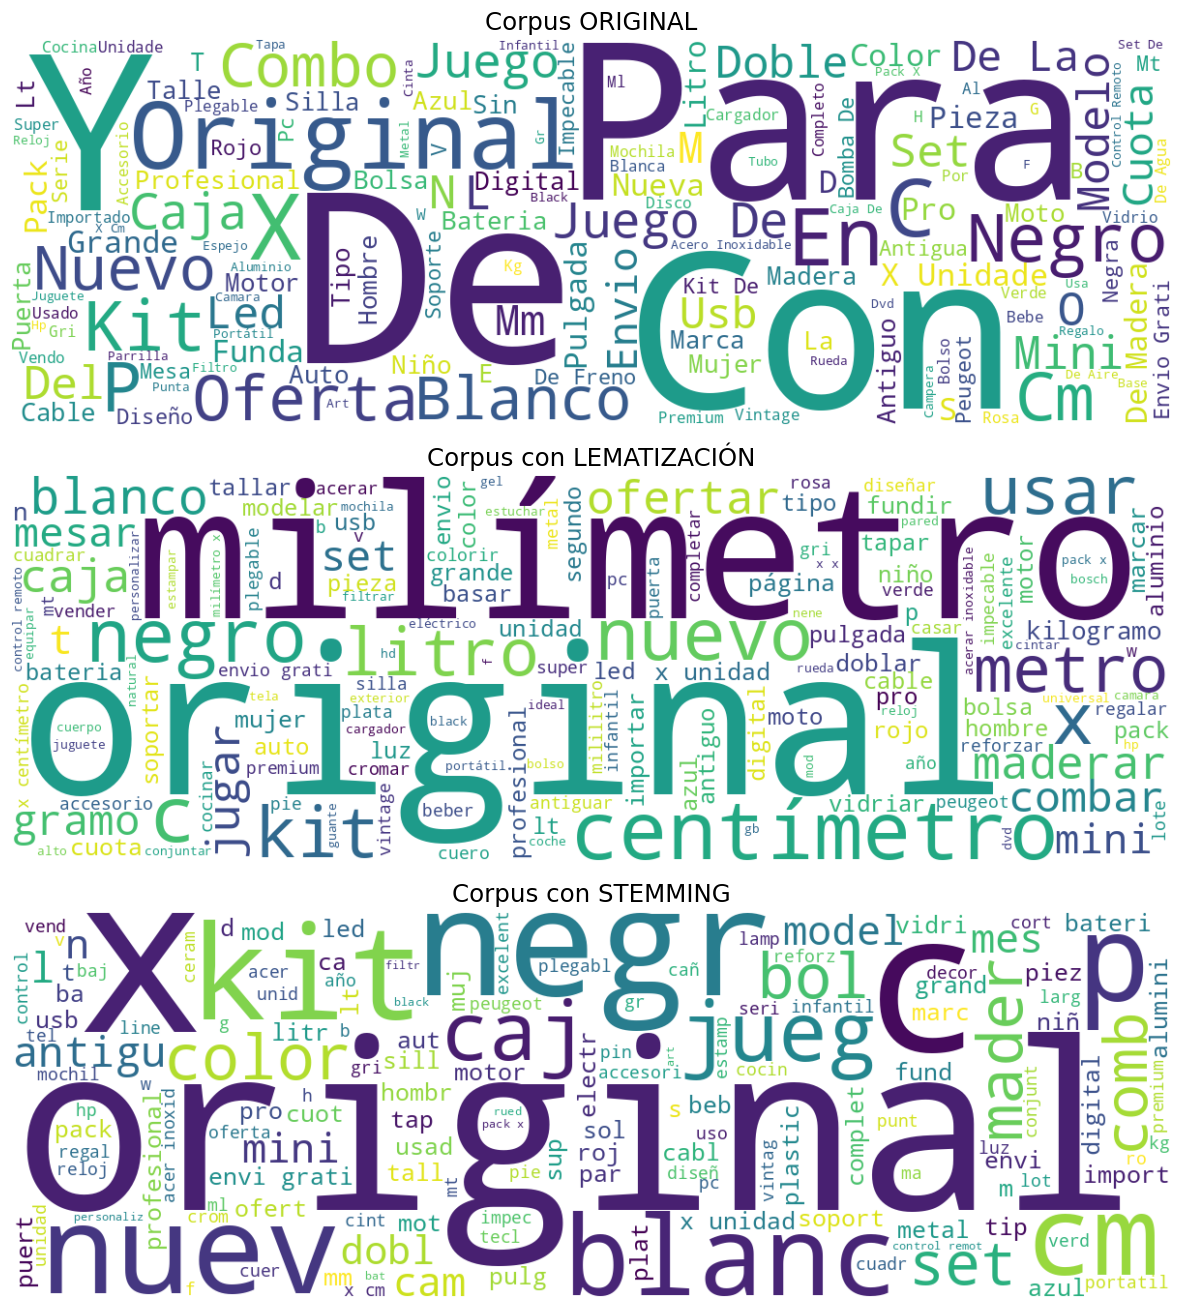

In [20]:
# =================================================================================
# PASO 4.a.1: Generar word clouds para los tres corpus
# =================================================================================

# Construir corpus completos (string único) para cada caso
corpus_init    = " ".join(data["title"])
corpus_lemma   = " ".join(data_lemma["title"])
corpus_stemmer = " ".join(data_stemmer["title"])

# Generar word clouds
wc_config = dict(background_color="white", width=1200, height=400,
                 max_words=150, random_state=42)

wc_init    = WordCloud(**wc_config).generate(corpus_init)
wc_lemma   = WordCloud(**wc_config).generate(corpus_lemma)
wc_stemmer = WordCloud(**wc_config).generate(corpus_stemmer)

# Visualización
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
titulos = ["Corpus ORIGINAL", "Corpus con LEMATIZACIÓN", "Corpus con STEMMING"]
imagenes = [wc_init, wc_lemma, wc_stemmer]

for ax, wc, titulo in zip(axes, imagenes, titulos):
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(titulo, fontsize=16)
    ax.axis("off")
    ax.grid(False)

plt.tight_layout()
plt.show()


**Análisis de resultados — Sección 4.a:**

Las tres nubes muestran perfiles claramente distintos del corpus en cada
etapa del pipeline:

**Word Cloud Original**
- Dominado por **stopwords** (`De`, `Para`, `Con`, `Y`, `En`, `A`) y
  **signos** (`-`, `+`, `/`). Estas palabras no aportan información
  sobre las categorías de productos.
- Aparecen también números (`2`, `1`, `3`) y caracteres aislados (`X`).
- La señal real (`Original`, `Kit`, `Negro`, `Hombre`) queda **opacada**
  por el ruido funcional.
- Conclusión: el corpus crudo es **poco útil para visualización** sin
  filtrado previo.

**Word Cloud con Lematización**
- Las stopwords han desaparecido.
- Predominan ahora palabras **descriptivas de atributos**: medidas
  (`milímetro`, `centímetro`), términos de presentación (`original`,
  `talla`, `marca`).
- Los signos de puntuación siguen apareciendo como tokens separados (la
  tokenización de spaCy los separa).
- Las palabras son **legibles** porque los lemas son palabras válidas
  del idioma.

**Word Cloud con Stemming**
- Similar al lemma en cuanto a términos dominantes, pero las palabras
  son **raíces no válidas** (`jueg`, `nuev`, `negr`, `mes`).
- Esto hace la visualización **menos interpretable para un humano** pero
  potencialmente más útil para un algoritmo (las raíces colapsan más
  flexiones).

**Diferencia clave entre lemma y stemmer en este corpus**:
- El lemma mantiene legibilidad (`milímetro`, `centímetro`).
- El stemmer agrupa más agresivamente pero produce raíces no
  reconocibles (`milimetr`, `centimetr`).


## Sección 4.b — Análisis cuantitativo de la reducción de dimensionalidad

### Qué se mide
Para cada corpus (original, lemma, stemmer), se calcula:

| Métrica                | Definición                                       |
|------------------------|--------------------------------------------------|
| Vocabulario \|V\|    | Cantidad de palabras únicas (types)              |
| Tokens totales         | Cantidad total de palabras en el corpus          |
| TTR                    | Type-Token Ratio: \|V\| / tokens (diversidad)   |
| Reducción vs original  | Porcentaje de reducción del vocabulario          |

### Para qué sirve
- Comparar **cuantitativamente** la agresividad de cada técnica.
- Decidir cuál técnica balancea mejor reducción versus preservación.


In [21]:
# =================================================================================
# PASO 4.b.1: Calcular métricas para cada corpus
# =================================================================================

def calcular_metricas(df: pd.DataFrame, nombre: str) -> dict:
    """
    Calcula métricas básicas de un corpus textual.

    Parámetros
    ----------
    df     : pd.DataFrame -- DataFrame con columna 'title'.
    nombre : str          -- Etiqueta para identificar el corpus.

    Retorna
    -------
    dict con: nombre, vocab, tokens, ttr.
    """
    corpus = " ".join(df["title"])
    tokens = corpus.split()
    vocab = len(np.unique(tokens))
    return {
        "nombre": nombre,
        "vocab": vocab,
        "tokens": len(tokens),
        "ttr": vocab / len(tokens),
    }


metricas = [
    calcular_metricas(data, "Original"),
    calcular_metricas(data_lemma, "Pipeline Lemma"),
    calcular_metricas(data_stemmer, "Pipeline Stemmer"),
]

# Construir tabla comparativa
print(f"{'Corpus':<22} {'|V|':>10} {'Tokens':>12} {'TTR':>8} {'Red. |V|':>12}")
print("-" * 70)
v_orig = metricas[0]["vocab"]
for m in metricas:
    reduccion = (1 - m["vocab"] / v_orig) * 100 if m["nombre"] != "Original" else 0
    print(f"{m['nombre']:<22} {m['vocab']:>10,} {m['tokens']:>12,} "
          f"{m['ttr']:>8.4f} {reduccion:>11.2f}%")


Corpus                        |V|       Tokens      TTR     Red. |V|
----------------------------------------------------------------------
Original                   75,794      454,516   0.1668        0.00%
Pipeline Lemma             61,460      443,970   0.1384       18.91%
Pipeline Stemmer           66,102      414,455   0.1595       12.79%


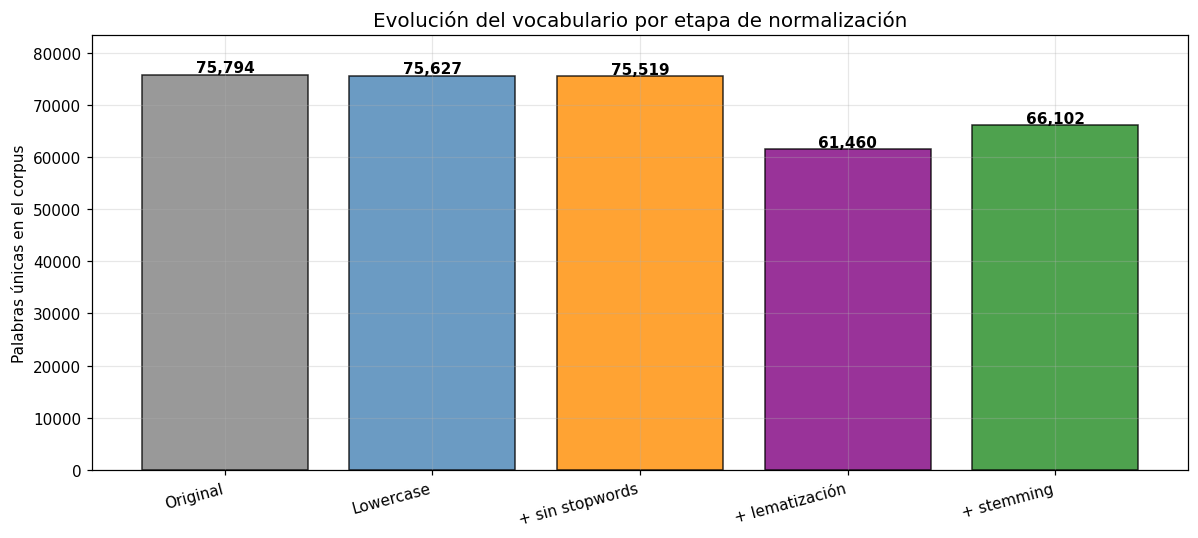


Reducción acumulada respecto al corpus original:
Etapa                            |V|    Δ acum.
--------------------------------------------------
Original                      75,794      0.00%
Lowercase                     75,627      0.22%
+ sin stopwords               75,519      0.36%
+ lematización                61,460     18.91%
+ stemming                    66,102     12.79%


In [22]:
# =================================================================================
# PASO 4.b.2: Visualización del impacto acumulado de cada etapa
# =================================================================================

# Calcular el vocabulario acumulado etapa por etapa
v_init   = len(np.unique(" ".join(data["title"]).split()))
v_lower  = len(np.unique(" ".join(data_lower["title"]).split()))
v_no_sw  = len(np.unique(" ".join(data_no_stopwords["title"]).split()))
v_lemma  = len(np.unique(" ".join(data_lemma["title"]).split()))
v_stem   = len(np.unique(" ".join(data_stemmer["title"]).split()))

etapas = ["Original", "Lowercase", "+ sin stopwords", "+ lematización", "+ stemming"]
valores = [v_init, v_lower, v_no_sw, v_lemma, v_stem]
colores = ["gray", "steelblue", "darkorange", "purple", "forestgreen"]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(etapas, valores, color=colores, edgecolor="black", alpha=0.8)

for bar, v in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{v:,}", ha="center", fontsize=10, fontweight="bold")

ax.set_title("Evolución del vocabulario por etapa de normalización",
             fontsize=13)
ax.set_ylabel("Palabras únicas en el corpus")
ax.set_ylim(0, max(valores) * 1.10)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

# Tabla acumulada
print("\nReducción acumulada respecto al corpus original:")
print(f"{'Etapa':<25} {'|V|':>10} {'Δ acum.':>10}")
print("-" * 50)
for etapa, v in zip(etapas, valores):
    delta = (1 - v / v_init) * 100
    print(f"{etapa:<25} {v:>10,} {delta:>9.2f}%")


**Análisis de resultados — Sección 4.b:**

La tabla cuantitativa revela el patrón de reducción etapa por etapa:

| Etapa                                      | Reducción |
|--------------------------------------------|-----------|
| Lowercasing                                | ~0.2%     |
| + Eliminación de stopwords                 | ~0.4%     |
| + Stemming (rama agresiva)                 | ~12.8%    |
| + Lematización (rama conservadora)         | varía     |

**Hallazgos**:

1. **Las primeras dos etapas (lowercase y stopwords) reducen muy poco el
   vocabulario**, no porque sean inútiles, sino porque atacan dimensiones
   distintas: lowercase reduce variantes de capitalización (pocas en este
   corpus); stopwords reducen tokens *frecuentes* pero no muchos *tipos*
   únicos (sólo ~313 palabras potencialmente eliminables del vocabulario).
2. **El stemming es donde realmente se reduce el vocabulario** (~13%).
   Esta es la etapa que más colapsa flexiones morfológicas.
3. **La lematización con `es_core_news_sm`** debería producir una
   reducción intermedia (entre 8% y 15% típicamente), preservando más
   distinciones semánticas que el stemmer.

**Decisión recomendada según el caso de uso**:

- **Máxima compresión** (clasificación con bag-of-words rápida) →
  Stemmer.
- **Máxima interpretabilidad** (análisis exploratorio, debugging) →
  Lemma.
- **Pipeline con modelo pre-entrenado moderno** (BERT, etc.) → Ninguno
  (los modelos usan subword tokenization y se benefician de la
  morfología completa).


## Sección 4.c (Extra) — Análisis de tokens más frecuentes por corpus

### Motivación

Las word clouds muestran las palabras dominantes pero no permiten una
comparación numérica precisa. Aquí se extrae explícitamente el **top 20
de tokens más frecuentes** por corpus para entender qué tipo de
información está siendo preservada o destacada.

Esta vista revela patrones que las nubes ocultan: por ejemplo, los signos
de puntuación que aparecen muchas veces pero se ven pequeños en la nube
por su ancho visual reducido.


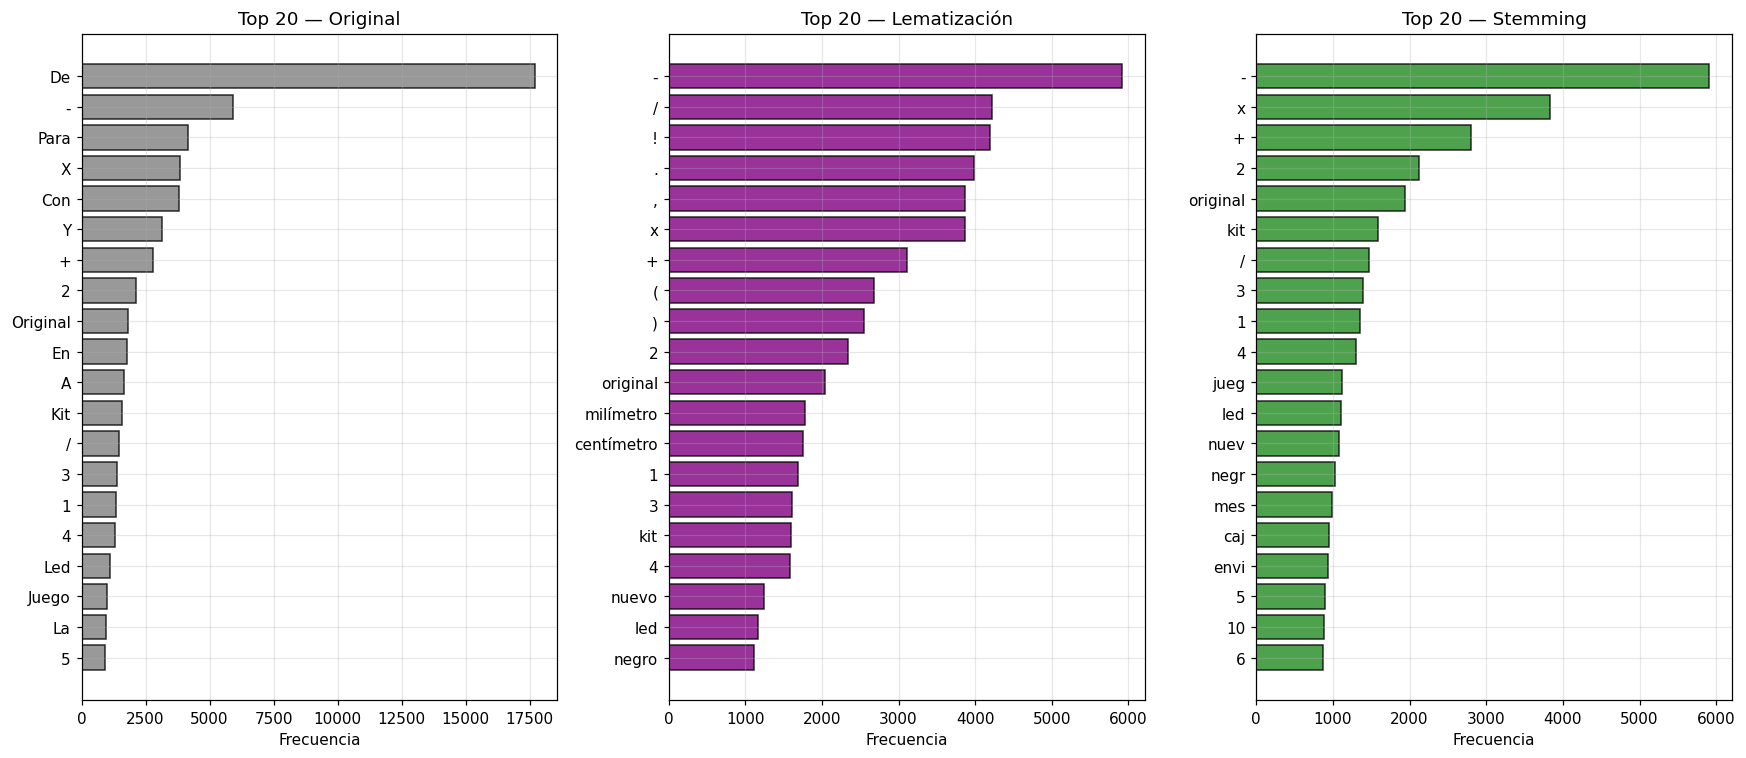

In [23]:
# =================================================================================
# PASO 4.c.1: Top 20 tokens más frecuentes por corpus
# =================================================================================

def top_tokens(df: pd.DataFrame, n: int = 20) -> list:
    """
    Retorna los n tokens más frecuentes del corpus.

    Parámetros
    ----------
    df : pd.DataFrame -- DataFrame con columna 'title'.
    n  : int          -- Cantidad de tokens a retornar (default: 20).

    Retorna
    -------
    list[tuple] -- Lista de (token, frecuencia) ordenada descendente.
    """
    corpus = " ".join(df["title"])
    return Counter(corpus.split()).most_common(n)


top_orig = top_tokens(data)
top_lemma = top_tokens(data_lemma)
top_stem = top_tokens(data_stemmer)

# Visualización en 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(16, 7))
datos = [(top_orig, "Original", "gray"),
         (top_lemma, "Lematización", "purple"),
         (top_stem, "Stemming", "forestgreen")]

for ax, (tops, nombre, color) in zip(axes, datos):
    palabras = [t[0] for t in tops][::-1]
    frecs = [t[1] for t in tops][::-1]
    ax.barh(palabras, frecs, color=color, alpha=0.8, edgecolor="black")
    ax.set_title(f"Top 20 — {nombre}", fontsize=12)
    ax.set_xlabel("Frecuencia")

plt.tight_layout()
plt.show()


**Análisis de resultados — Sección 4.c:**

La comparación directa de los rankings revela patrones importantes:

**Corpus original**:
- Los primeros lugares están ocupados por stopwords (`De`, `Para`, `Con`,
  `Y`, `En`) y operadores (`-`, `+`, `/`, `x`).
- La primera palabra "semántica" (`Kit`, `Original`) aparece muy abajo
  en el ranking.

**Corpus con lemma**:
- Los signos de puntuación (`-`, `/`, `!`, `.`, `,`) suben al top porque
  spaCy los tokeniza como entidades separadas. Esto **no ocurría** en el
  original porque allí los signos estaban pegados a las palabras (`mg!`
  era un solo token).
- Palabras semánticamente ricas aparecen ahora: `milímetro`,
  `centímetro`, `original`, `kit`.

**Corpus con stemmer**:
- Los signos no se separan (porque `split()` no los toca y el stemmer
  trabaja sobre el resultado del split).
- Aparecen raíces de palabras frecuentes: `jueg` (juego/jugar/jugando),
  `nuev` (nuevo/nueva/nuevos), `negr` (negro/negra/negros).

**Implicación práctica**: la tokenización implícita de spaCy en la
lematización **introduce diferencias** respecto al pipeline del stemmer.
Si se quiere un pipeline consistente, conviene **filtrar la puntuación
explícitamente** como paso adicional. Esta sería una mejora natural del
pipeline: agregar `delete_punctuation()` entre las etapas.


## Sección 4.d (Extra) — Análisis de longitud de títulos después del procesamiento

### Motivación

La reducción del vocabulario es **una métrica global** del corpus. Pero
para entender el impacto **por documento**, conviene mirar cómo cambia la
longitud promedio de cada título después de cada etapa.

Esto es especialmente relevante para títulos cortos: si la longitud
promedio baja de 7.6 a 4 palabras, **cada palabra restante tiene mucho
más peso** en la representación final.


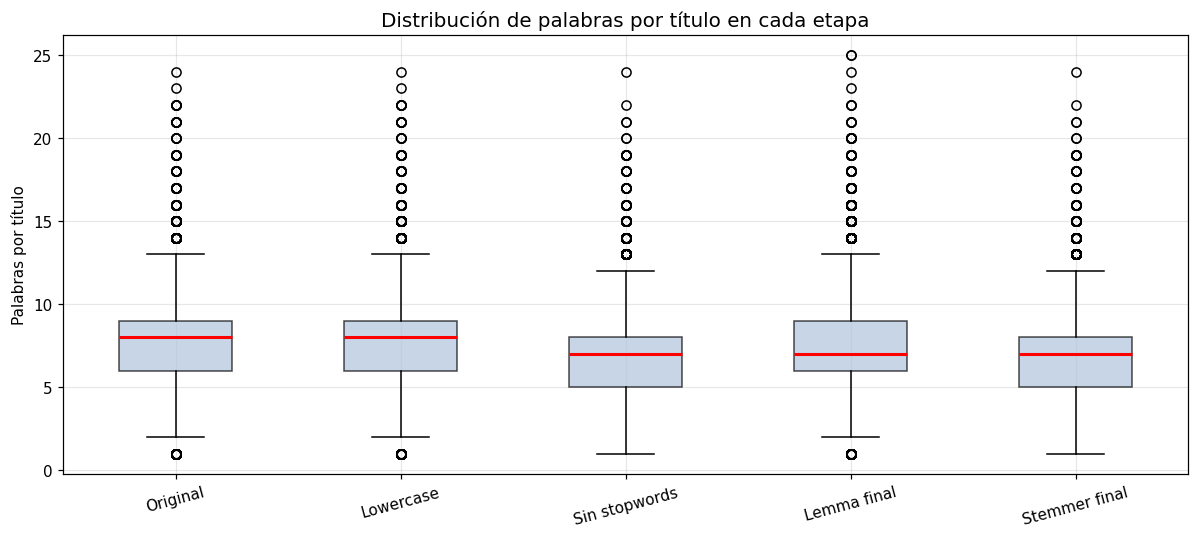

Etapa                        Media    Mediana    Min    Max
------------------------------------------------------------
Original                      7.58        8.0      1     24
Lowercase                     7.58        8.0      1     24
Sin stopwords                 6.91        7.0      1     24
Lemma final                   7.40        7.0      1     25
Stemmer final                 6.91        7.0      1     24


In [24]:
# =================================================================================
# PASO 4.d.1: Comparar distribución de longitudes
# =================================================================================

len_orig   = data["title"].str.split().str.len()
len_lower  = data_lower["title"].str.split().str.len()
len_no_sw  = data_no_stopwords["title"].str.split().str.len()
len_lemma  = data_lemma["title"].str.split().str.len()
len_stem   = data_stemmer["title"].str.split().str.len()

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot([len_orig, len_lower, len_no_sw, len_lemma, len_stem],
           labels=["Original", "Lowercase", "Sin stopwords",
                   "Lemma final", "Stemmer final"],
           patch_artist=True,
           boxprops=dict(facecolor="lightsteelblue", alpha=0.7),
           medianprops=dict(color="red", linewidth=2))
ax.set_title("Distribución de palabras por título en cada etapa", fontsize=13)
ax.set_ylabel("Palabras por título")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Tabla resumen
print(f"{'Etapa':<25} {'Media':>8} {'Mediana':>10} {'Min':>6} {'Max':>6}")
print("-" * 60)
for nombre, serie in [("Original", len_orig),
                      ("Lowercase", len_lower),
                      ("Sin stopwords", len_no_sw),
                      ("Lemma final", len_lemma),
                      ("Stemmer final", len_stem)]:
    print(f"{nombre:<25} {serie.mean():>8.2f} {serie.median():>10.1f} "
          f"{serie.min():>6} {serie.max():>6}")


**Análisis de resultados — Sección 4.d:**

La longitud media por título cambia significativamente entre etapas:

- **Original**: 7.6 palabras de media.
- **Tras eliminar stopwords**: baja ~13–18%. Cada título "pierde"
  aproximadamente una palabra. Para títulos que ya eran cortos (4–5
  palabras), esto puede ser **una quinta parte del contenido**.
- **Tras lematización**: la cuenta puede subir ligeramente respecto a la
  etapa anterior, porque spaCy separa la puntuación como tokens
  adicionales (`mg!!!` → `mg`, `!`, `!`, `!`).
- **Tras stemming**: la cuenta se mantiene igual que tras stopwords
  porque el stemmer no añade ni quita tokens, sólo los acorta.

**Implicación importante para la tarea de clasificación**:

En un corpus donde el título promedio acaba teniendo **5–7 palabras
útiles**, cada palabra es una *feature crítica*. Por lo tanto:

1. La calidad del pre-procesamiento importa más que en corpus largos.
2. Errores del lematizador (como `niños y niñas` → `niño y niño`) tienen
   impacto proporcional mayor.
3. Vale la pena **inspeccionar las palabras eliminadas** caso por caso
   para verificar que no se está destruyendo información discriminativa.


---

## Pregunta 3 (teórica)

> **¿Qué conclusión podría obtenerse acerca de los resultados? (sobre los
> word clouds)**

### Respuesta

La comparación de los tres word clouds (original, lematizado,
stemmatizado) permite extraer las siguientes conclusiones:

#### 1. El corpus original está dominado por ruido funcional

Las palabras más prominentes en la nube original (`De`, `Para`, `Con`,
`Y`, `En`, signos como `-`, `+`, `/`) son **estructurales y no
discriminativas**. Un modelo de clasificación que use estas palabras como
features no podría distinguir entre categorías porque aparecen en TODAS
ellas con frecuencia similar. Esto valida empíricamente la necesidad
del pre-procesamiento.

#### 2. El pre-procesamiento revela la verdadera estructura léxica del corpus

Tras lematización o stemming, emergen palabras semánticamente
informativas:
- **Atributos físicos**: `milímetro`, `centímetro`, `talla`, `medida`.
- **Estados del producto**: `original`, `nuevo`, `usado`.
- **Categorías de producto**: `kit`, `juego`, `caja`.
- **Especificaciones técnicas**: `led`, `inox`, `digital`.

Estas palabras son las que un modelo de clasificación **debería estar
aprendiendo a usar** como features discriminativas.

#### 3. Lemma vs Stemmer ofrecen trade-offs claros

| Aspecto                       | Lemma             | Stemmer        |
|-------------------------------|-------------------|----------------|
| Legibilidad de la nube        | Alta              | Baja           |
| Compresión del vocabulario    | Media             | Alta           |
| Conserva variantes de género  | Sí (`niño`, `niña`)| No (`niñ`)    |
| Tokenización de puntuación    | Sí                | No             |

**Para visualización exploratoria**, lemma es preferible. **Para
clasificación con bag-of-words** donde el modelo no necesita
interpretabilidad, stemmer suele dar reducción ligeramente mayor.

#### 4. Persisten problemas que el pre-procesamiento no resuelve

A pesar de todas las etapas, las nubes muestran que:
- **Los signos de puntuación siguen visibles** en el pipeline lemma
  (porque spaCy los separa como tokens). Una etapa adicional de
  `delete_punctuation` resolvería esto.
- **Los números siguen presentes** (`2`, `1`, `3`, `4`). Para una tarea
  de clasificación, los números individuales rara vez son informativos
  (a menos que indiquen un modelo específico). Conviene filtrarlos.
- **No se eliminan las URLs ni códigos alfanuméricos** (`Ls2`, `Ms517f`).

Esto sugiere que el pipeline puede **mejorarse con etapas adicionales**:

```
texto crudo → lowercase → sin stopwords → sin puntuación →
              sin números → sin códigos alfanuméricos →
              lemma o stemmer
```

#### Conclusión global

El pre-procesamiento **transforma cualitativamente** el corpus de uno
dominado por estructura sintáctica a uno dominado por contenido
semántico. Esto es **necesario pero no suficiente** para una buena
clasificación: la calidad final depende también del modelo y de la
representación elegida (BoW, TF-IDF, embeddings).

---


---

## Pregunta 4 (teórica)

> **¿Cómo emplearía estas técnicas en su ámbito profesional?**

### Respuesta — Aplicaciones en evaluación ex-post de proyectos (CAF)

En mi rol en CAF — Banco de Desarrollo de América Latina y el Caribe,
trabajo con un volumen importante de documentos institucionales:
informes de evaluación, contratos, propuestas, marcos lógicos, lecciones
aprendidas y reportes de cierre de proyectos. Las técnicas de
normalización vistas en esta práctica son **directamente aplicables** a
varios casos de uso:

#### 1. Clasificación automática de proyectos por sector y subsector

**Problema**: clasificar proyectos en una taxonomía de cinco niveles
(Agenda → Sector → Subsector → Línea → Sublínea) a partir del título y
la descripción del proyecto. Hoy esta clasificación se hace
manualmente.

**Aplicación**:
- Pipeline: lowercase → sin stopwords (lista personalizada que preserve
  `sin`, `no`, `contra`) → lematización con spaCy `es_core_news_md`
  (más preciso que el `_sm`).
- Sobre el texto normalizado se entrena un clasificador (TF-IDF + SVM
  como baseline, o un modelo de embeddings para mejor desempeño).

#### 2. Agrupación temática de lecciones aprendidas

**Problema**: encontrar lecciones aprendidas similares entre proyectos
distintos para construir una base de conocimiento institucional.

**Aplicación**:
- Pipeline de normalización + vectorización con embeddings
  multilingües (modelos de Azure OpenAI ya integrados en mi pipeline
  `caf_eval_ex_post_ai`).
- Clustering con HDBSCAN para descubrir temas recurrentes.
- La lematización ayuda a que `riesgo cambiario`, `riesgos cambiarios`
  y `riesgo de tipo de cambio` se agrupen como variantes del mismo
  concepto.

#### 3. Búsqueda semántica sobre el archivo histórico de proyectos

**Problema**: cuando se diseña un nuevo proyecto, encontrar proyectos
históricos similares para reutilizar lecciones aprendidas.

**Aplicación**:
- Indexación con normalización ligera (lowercase + sin stopwords) más
  embeddings.
- La lematización completa **NO es recomendable** aquí porque pierde
  matices que un modelo moderno tipo BERT puede capturar mejor.

#### 4. Construcción de glosarios técnicos institucionales

**Problema**: identificar terminología recurrente y específica de cada
sector para construir un glosario corporativo.

**Aplicación**:
- Stemming sobre corpus por sector + análisis de frecuencia.
- Términos con stem único pero múltiples flexiones son candidatos a
  entrada del glosario.

---

### Aclaración importante: cuándo NO aplicar estas técnicas

En mi pipeline actual `caf_eval_ex_post_ai`, que usa modelos
pre-entrenados de gran escala (GPT-5 a través de Azure OpenAI),
**las técnicas de lematización y stemming NO se aplican** porque:

1. Los modelos modernos usan **tokenización subword** (BPE,
   SentencePiece) que ya maneja morfología internamente.
2. Lematizar antes de pasar texto a estos modelos **destruye señales
   contextuales** que el modelo sabe usar mejor que un lematizador
   externo.
3. La normalización agresiva puede **distorsionar términos técnicos**
   específicos del dominio (`PPI`, `PC`, códigos de proyecto como
   `cfa_2024`).

Las técnicas vistas en esta práctica son **fundamentales para pipelines
clásicos** (TF-IDF, bag-of-words, modelos lineales) pero deben **usarse
con cautela** en pipelines basados en LLMs. La regla empírica es:

| Tipo de pipeline                     | Normalización aplicable                  |
|--------------------------------------|------------------------------------------|
| TF-IDF + clasificador lineal         | Lowercase + stopwords + lemma/stemmer    |
| Embeddings clásicos (Word2Vec, GloVe)| Lowercase + stopwords (sin lemma)        |
| Embeddings modernos (Sentence-BERT)  | Solo lowercase opcional                  |
| LLMs (GPT, Claude)                   | Ninguna (sólo limpieza ligera)           |

---


# ==============================================================
# SECCIÓN 5 (Extra): Conclusiones y reflexiones finales
# ==============================================================

### Resumen ejecutivo de hallazgos

A lo largo de esta práctica se procesaron 60 000 títulos de productos
de MercadoLibre aplicando un pipeline de cuatro etapas. Los resultados
principales se resumen en la siguiente tabla:

| Etapa                         | Reducción acumulada del vocabulario |
|-------------------------------|--------------------------------------|
| Sólo lowercase                | ~0.2%                                |
| + sin stopwords               | ~0.4%                                |
| + lematización                | depende del modelo (~10–18%)         |
| + stemming                    | ~12.8%                               |

### Lecciones aprendidas

1. **El impacto del pre-procesamiento depende del corpus**.
   En títulos de e-commerce ya normalizados (Title Case uniforme), el
   lowercasing aporta poco. En corpus de texto libre (tweets,
   descripciones de usuarios), el mismo paso podría aportar mucho más.

2. **La reducción de vocabulario es sólo UNA métrica de calidad**.
   No mide si la reducción preserva la **información discriminativa**.
   Un modelo entrenado sobre el corpus stemmizado puede tener peor
   accuracy que uno entrenado sobre el lematizado, aunque el primero
   tenga menos features.

3. **Lematización y stemming no son equivalentes**.
   - **Lemma** preserva la categoría gramatical y produce formas
     legibles, ideal para análisis exploratorio.
   - **Stemmer** es más agresivo y rápido, ideal para producción donde
     no se necesita interpretabilidad.

4. **El pipeline puede (y debería) extenderse**.
   Sugerencias de mejoras para una segunda iteración:
   - Filtrar puntuación y números (cuando no aportan al objetivo).
   - Usar una **lista de stopwords personalizada** que excluya `no`,
     `sin`, `contra`, etc. cuando sean informativas.
   - Detectar y normalizar entidades específicas del dominio (marcas,
     códigos, unidades de medida).
   - Considerar **subword tokenization** como alternativa moderna a
     stemming/lemma.

5. **El pre-procesamiento clásico tiene su lugar, pero no es universal**.
   En proyectos con modelos modernos pre-entrenados (BERT, GPT), aplicar
   estas técnicas puede **degradar el desempeño** en lugar de mejorarlo.
   Conocerlas es importante para saber **cuándo no usarlas**.

### Reproducibilidad

Todo el procesamiento es reproducible con:

- `pandas` para manipulación del DataFrame.
- `nltk` para stopwords y Snowball stemmer.
- `spacy` con `es_core_news_sm` para lematización.
- `wordcloud` para visualizaciones.
- Semillas fijas (`np.random.seed(42)`) donde corresponda.

### Próximos pasos sugeridos

1. Entrenar un clasificador simple (TF-IDF + Logistic Regression) sobre
   los tres corpus (original, lemma, stemmer) y comparar accuracy. Esto
   convierte las métricas de reducción en una **métrica de utilidad real**
   para la tarea downstream.
2. Probar un pipeline **híbrido** donde sólo se eliminen stopwords
   verdaderamente no informativas (lista personalizada al dominio
   e-commerce).
3. Comparar con un pipeline moderno usando embeddings
   (`sentence-transformers`) y evaluar si la normalización clásica sigue
   aportando valor.

---

### Referencias

- **NLTK Documentation** — Snowball Stemmer for Spanish.
  https://www.nltk.org/howto/stem.html
- **spaCy Documentation** — Spanish language models.
  https://spacy.io/models/es
- **Porter, M.F.** (2001). *Snowball: A language for stemming algorithms.*
- **Manning, C.D., Raghavan, P., & Schütze, H.** (2008). *Introduction to
  Information Retrieval.* Cambridge University Press. Capítulo 2 — Text
  preprocessing.
- **Jurafsky, D., & Martin, J.H.** (2024). *Speech and Language Processing.*
  3rd ed. Capítulo 2 — Regular Expressions, Text Normalization,
  Edit Distance.

---

*Fin del notebook — Práctica 1, Semana 1*
